In [2]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

# Loading the audio records of 2 different voices, plotting them as waveforms and displaying the metadata

Sample Rate:  8000
Duration:  4.76
Shape:  (38080,)

Sample Rate:  8000
Duration:  4.76
Shape:  (38080,)


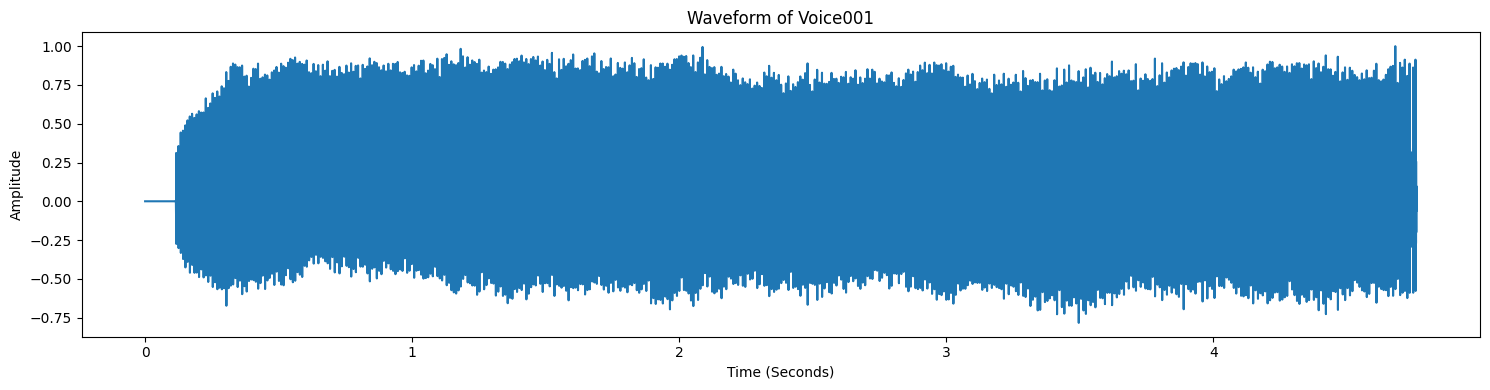

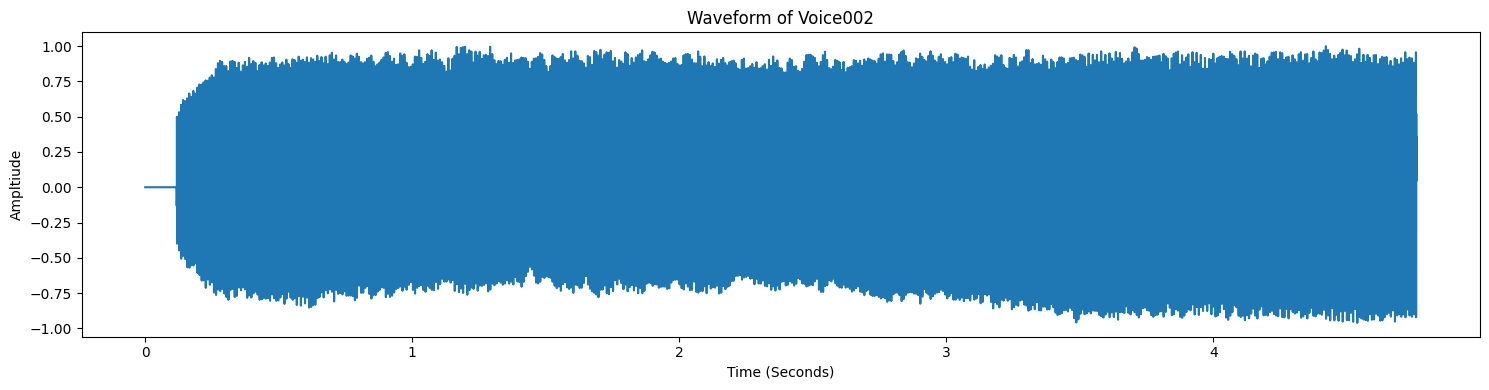

In [37]:
voice001, sr001 = librosa.load("C:\\Users\\ernun\\OneDrive\\Desktop\\VoicePathologyClassification\\voice001.wav", sr=None)
voice002, sr002 = librosa.load("C:\\Users\\ernun\\OneDrive\\Desktop\\VoicePathologyClassification\\voice002.wav", sr=None)

duration001 = len(voice001) / sr001
print("Sample Rate: ", sr001)
print("Duration: ", duration001)
print("Shape: ", voice001.shape)
print()
print("Sample Rate: ", sr002)
print("Duration: ", len(voice002) / sr002)
print("Shape: ", voice002.shape)

time001 = np.linspace(0, len(voice001)/sr001, num=len(voice001))
time002 = np.linspace(0, len(voice002)/sr002, num=len(voice002))

plt.figure(figsize=(15,4))
plt.plot(time001, voice001)
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.title("Waveform of Voice001")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,4))
plt.plot(time002, voice002)
plt.xlabel("Time (Seconds)")
plt.ylabel("Ampltiude")
plt.title("Waveform of Voice002")
plt.tight_layout()
plt.show()

# Zooming in on the waveform, visualizing the audio signals in a 50 milisecond frame, plotting the fourier transform of voice002 (healthy voice)

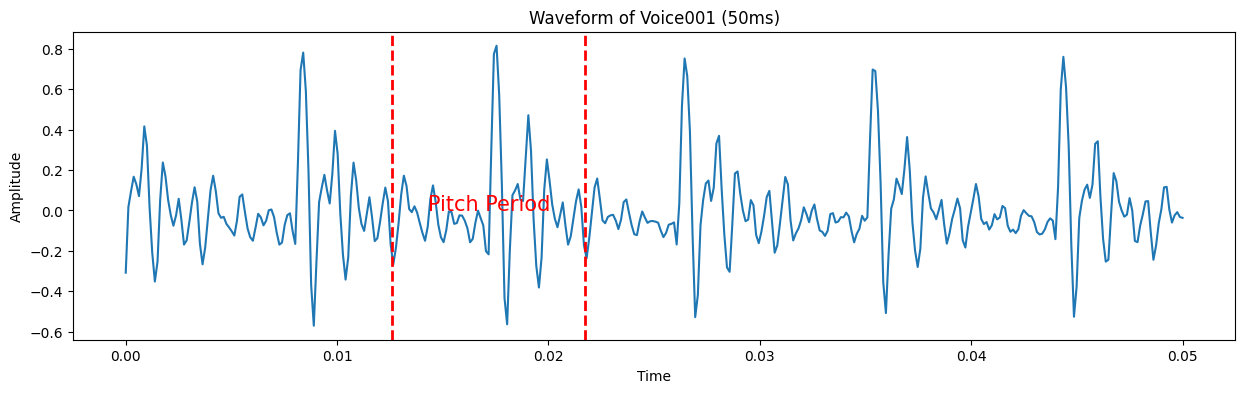

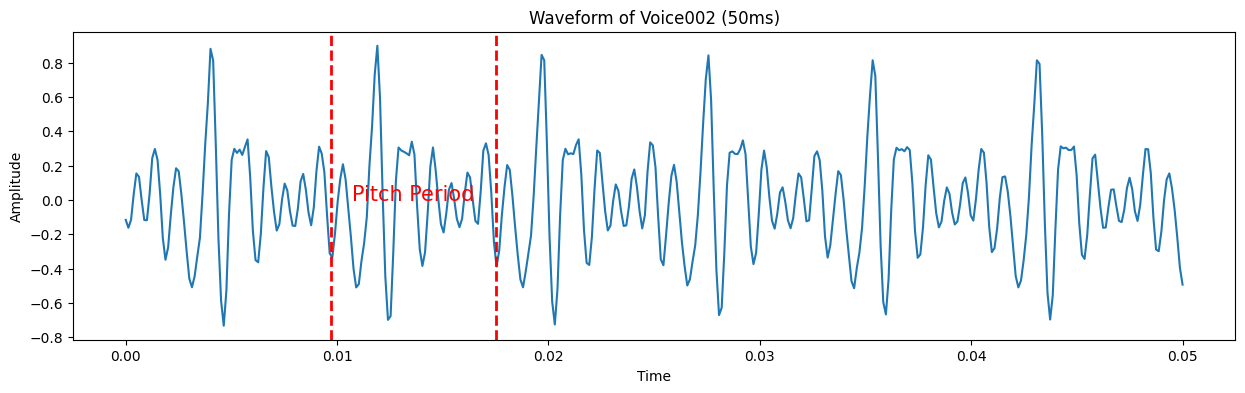

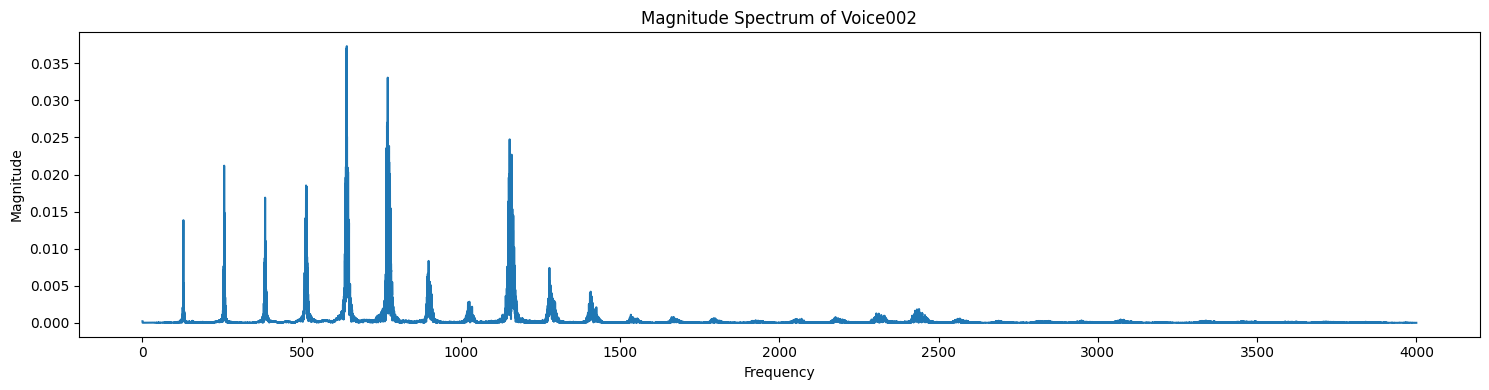

In [33]:
sr001_50ms = int(sr001 * 0.05)
voice001_zoom = voice001[len(voice001) // 2 - sr001_50ms //2 :len(voice001) // 2 + sr001_50ms // 2]
time001_zoom = np.linspace(0, 0.05,num=len(voice001_zoom))

plt.figure(figsize=(15,4))
plt.plot(time001_zoom, voice001_zoom)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Waveform of Voice001 (50ms)")
plt.text((0.0126 + 0.02175) / 2,00, "Pitch Period",c="red",ha="center",fontsize=15)
plt.axvline(x=0.0126, color='red', linewidth=2,linestyle="--")
plt.axvline(x=0.02175, color='red', linewidth=2,linestyle="--")
plt.show()

sr002_50ms = int(sr002 * 0.05)
voice002_zoom = voice002[len(voice002) // 2 - sr002_50ms // 2: len(voice002) // 2 + sr002_50ms // 2]
time002_zoom = np.linspace(0, 0.05, num = len(voice002_zoom))

plt.figure(figsize=(15,4))
plt.plot(time002_zoom, voice002_zoom)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Waveform of Voice002 (50ms)")
plt.text((0.0097 + 0.0175) / 2,00, "Pitch Period",c="red",ha="center",fontsize=15)
plt.axvline(x=0.0097, color='red', linewidth=2,linestyle="--")
plt.axvline(x=0.0175, color='red', linewidth=2,linestyle="--")
plt.show()

voice002_fft = np.abs(np.fft.fft(voice002)) / len(voice002)
frequencies002 = np.fft.fftfreq(len(voice002_fft),d=1/sr002)


plt.figure(figsize=(15,4))
plt.plot(frequencies002[:len(voice002) // 2], voice002_fft[:len(voice002) // 2])
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum of Voice002")
plt.tight_layout()
plt.show()



# Plotting the spectogram of voice002

(1025, 75)


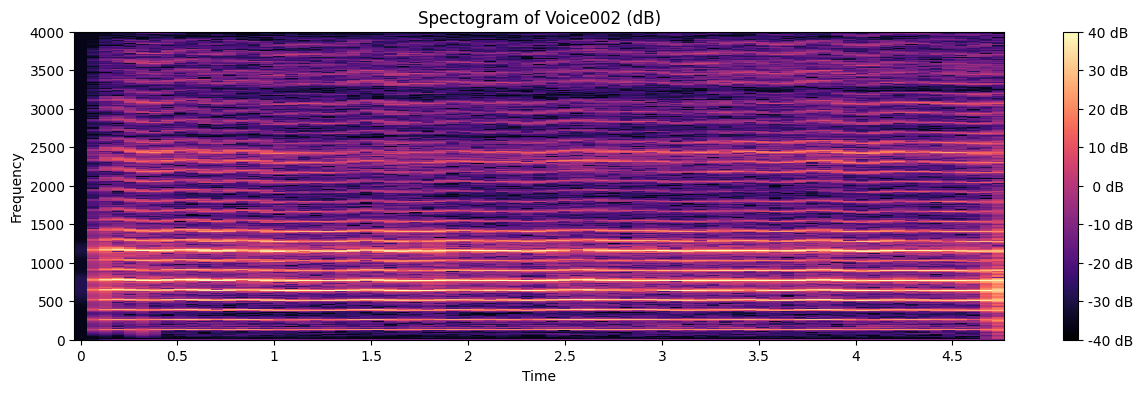

In [34]:
voice002_stft = librosa.stft(voice002)
voice002_stft_dB = librosa.amplitude_to_db(np.abs(voice002_stft))
print(voice002_stft.shape)
plt.figure(figsize=(15,4))
librosa.display.specshow(voice002_stft_dB,sr=sr002,x_axis="time",y_axis="hz",cmap="magma",vmin=-40,vmax=40)
plt.colorbar(format="%2.0f dB")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Spectogram of Voice002 (dB)")
plt.show()

# Plotting the spectogram of voice001

(38080,)


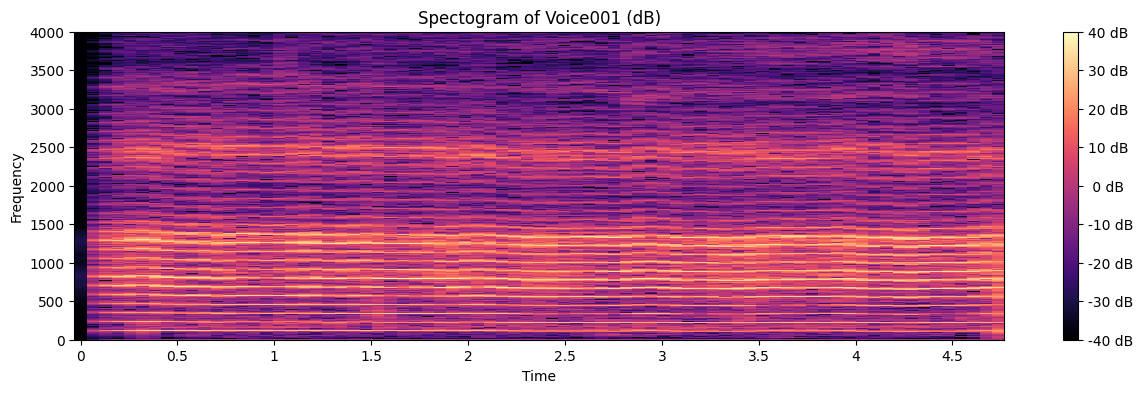

In [35]:
voice001_stft = librosa.stft(voice001)
voice001_stft_dB = librosa.amplitude_to_db(np.abs(voice001_stft))
print(voice001.shape)

plt.figure(figsize=(15,4))
librosa.display.specshow(voice001_stft_dB,sr=sr001,x_axis="time",y_axis="hz",cmap="magma",vmin=-40,vmax=40)
plt.colorbar(format="%2.0f dB")
plt.title("Spectogram of Voice001 (dB)")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()